<div>
<img src="https://i.ibb.co/v3CvVz9/udd-short.png" width="150"/>
    <br>
    <strong>Universidad del Desarrollo</strong><br>
    <em>Magíster en Data Science</em><br>
    <em>Profesor: Takeshi Asahi Kodama</em><br>

</div>

# **<center>SISTEMA DE CLASIFICACIÓN DE IMÁGENES</center>**
*11 de junio de 2025*

**Nombre Estudiante**: Cristian Tobar Morales  
**Asignatura**: Visión Computacional 

## **TABLA DE CONTENIDO**

01. Introducción
02.	Objetivo
03.	Metodología
04.	Descripción de la base de datos
05.	Desarrollo
    *   Carga y análisis exploratorio
        -   Librerías requeridas 
        -	Información inicial del dataset
        -	Ingreso de los datos
        -	Visualización
    *	Dataset de entrenamiento y prueba
    *	Preprocesamiento de los datos
        -	Normalización 
        -	Aumento de datos    
        -	Eliminar ruido
    *	Convertir el generador
    *	Redes neuronales Convolucionales 
        -	Creación y compilación del modelo
06.	Análisis del desempeño de los modelos
07.	Conclusiones 

## **01. INTRODUCCIÓN**
El presente informe detalla una base de datos correspondiente a imágenes de cobertura terrestre, con el fin del preprocesamiento la cual cuenta con diferentes coberturas en sus datos.

La base de datos fue obtenida de la plataforma en línea [Kaggle][DataSet], la cual se especializa en ciencia de datos y Machine Learning.

Este conjunto de datos corresponde a imágenes de cobertura terrestre registradas por el satélite Sentinel-2, diseñado para la clasificación de tipos de suelo y aplicaciones de teledetección. El registro cuenta con 10 clases distintas de cobertura.

[DataSet]: https://www.kaggle.com/datasets/salmaadell/eurosat-rgb 


## **02. OBJETIVO**
Desarrollar un sistema de procesamiento y análisis de imágenes, para realizar mediciones. 

## **03. METODOLOGÍA**
-	**Carga y análisis exploratorio de los datos**  
Se ingresan los datos crudos para observar la resolución que poseen, se toma con referencia la primera imagen de cada clase de terreno.
-	**Dataset de entrenamiento y prueba**  
Se divide el conjunto total de imágenes de modo que el 80% de ellas se utilicen para ajustar el modelo, y el 20% restante para evaluar la capacidad de generalización del mismo. 
-	**Preprocesamiento de los datos**  
Se realiza para transformar los datos crudos en una forma que sea mas adecuada para ser ingresadas el modelo. 
-	**Convertir el generador**   
Para obtener X_train, y_train, X_test y y_test de tus generadores de datos train_dataset y test_dataset.
-	**Redes neuronales convolucionales**    
-	**Análisis de desempeño**  
Se evalúa el desempeño del modelo de clasificación, mediante la precisión, recall y F1-score.


## **04. DESCRIPCIÓN DE LA BASE DE DATOS**
El dataset contiene imágenes de cobertura terrestres registradas por el satélite Sentinel-2, diseñados para la clasificación de tipos de suelo y aplicaciones de teledetección. La base de datos contiene un conjunto de diez clases distintas de cobertura. 

Los terrenos que cubre:
-	**Bosque (Forest):** Áreas densamente arboleadas, incluidos bosques naturales y plantaciones.
-	**Residencial (Residential):** Regiones urbanas y suburbanas con casas, edificios y asentamientos.  
-	**Vegetación Herbácea (Herbaceous Vegetation):** Pastizales, arbustos y plantas no leñosas. 
-	**Mar/Lago (Sea/Lake):** Grandes masa de agua, incluidos mares, lagos y océanos. 
-	**Cultivo Anual (Annual Crop):** Tierras de cultivo, con cultivos desde que se planta y cosechan en un solo año.
-	**Industrial:** Áreas con fábricas, almacenes e instalaciones de fabricación. 
-	**Río (River):** Cuerpos de agua que fluyen, como ríos y arroyos. 
-	**Autopista (Highway):** Carreteras principales, autopistas y rutas de transporte. 
-	**Cultivo permanente (Permanent Crop):** Terrenos con cultivo que crecen de forma continua, como viñedos y huertos. 
-	**Pastizales (Pasture):** Pastizales utilizados para el pastoreo del ganado.

## **05. DESARROLLO**

### **CARGA Y ANÁLISIS EXPLORATORIO DE LOS DATOS**

#### Librerías requeridas

In [1]:
import os
import json
from PIL import Image, UnidentifiedImageError, ImageFilter
from IPython.display import display  # Para mostrar imágenes en Jupyter Notebook
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.model_selection import train_test_split
from tensorflow.io import parse_single_example, FixedLenFeature
#import tensorflow_addons as tfa

In [2]:
# Optimizar rendimiento en CPU
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'  # Acelera operaciones con OneDNN
os.environ['OMP_NUM_THREADS'] = '4'        # Usa 4 núcleos de tu CPU

#### Información inicial del dataset

In [3]:
# Ruta para obtener información general de las imágenes 
image_path = 'data/image.image.json'

with open(image_path, 'r') as f:
    image_info = json.load(f)

print("\033[1mINFORMACIÓN GENERAL DE IMÁGENES\033[0m")
print(json.dumps(image_info, indent=2, sort_keys=True))


INFORMACIÓN GENERAL DE IMÁGENES
{
  "encoding_format": "png",
  "shape": [
    64,
    64,
    3
  ]
}


In [4]:
label_path = 'data/label.labels.txt'
with open(label_path, 'r') as f:
    label_names = f.read().splitlines()

print("\033[1mLISTA DE ETIQUETAS\033[0m")
print(f'Cantidad: {len(label_names)}\n')
print("\n".join(label_names))

LISTA DE ETIQUETAS
Cantidad: 10

AnnualCrop
Forest
HerbaceousVegetation
Highway
Industrial
Pasture
PermanentCrop
Residential
River
SeaLake


#### Ingreso de los datos

In [5]:
# Ruta al TFRecord
tfrecord_file = 'data/eurosat-train.tfrecord-00000-of-00001'

# Crear el dataset en crudo
dataset = tf.data.TFRecordDataset(tfrecord_file)

# Definir la descripción de las características basándose en el TFRecord
feature_description = {
    'image': tf.io.FixedLenFeature([], tf.string),
    'label': tf.io.FixedLenFeature([], tf.int64)
}

def _parse_function(example_proto):
    parsed_features = tf.io.parse_single_example(example_proto, feature_description)
    # Usa decode_png ya que tus imágenes son PNG
    image = tf.io.decode_png(parsed_features['image'], channels=3)
    label = parsed_features['label']
    return image, label

parsed_dataset = dataset.map(_parse_function)

#### Visualización 
Se imprime una imagen por cada clase de terreno, con el objetivo de observar los archivos entregados para dicho estudio.

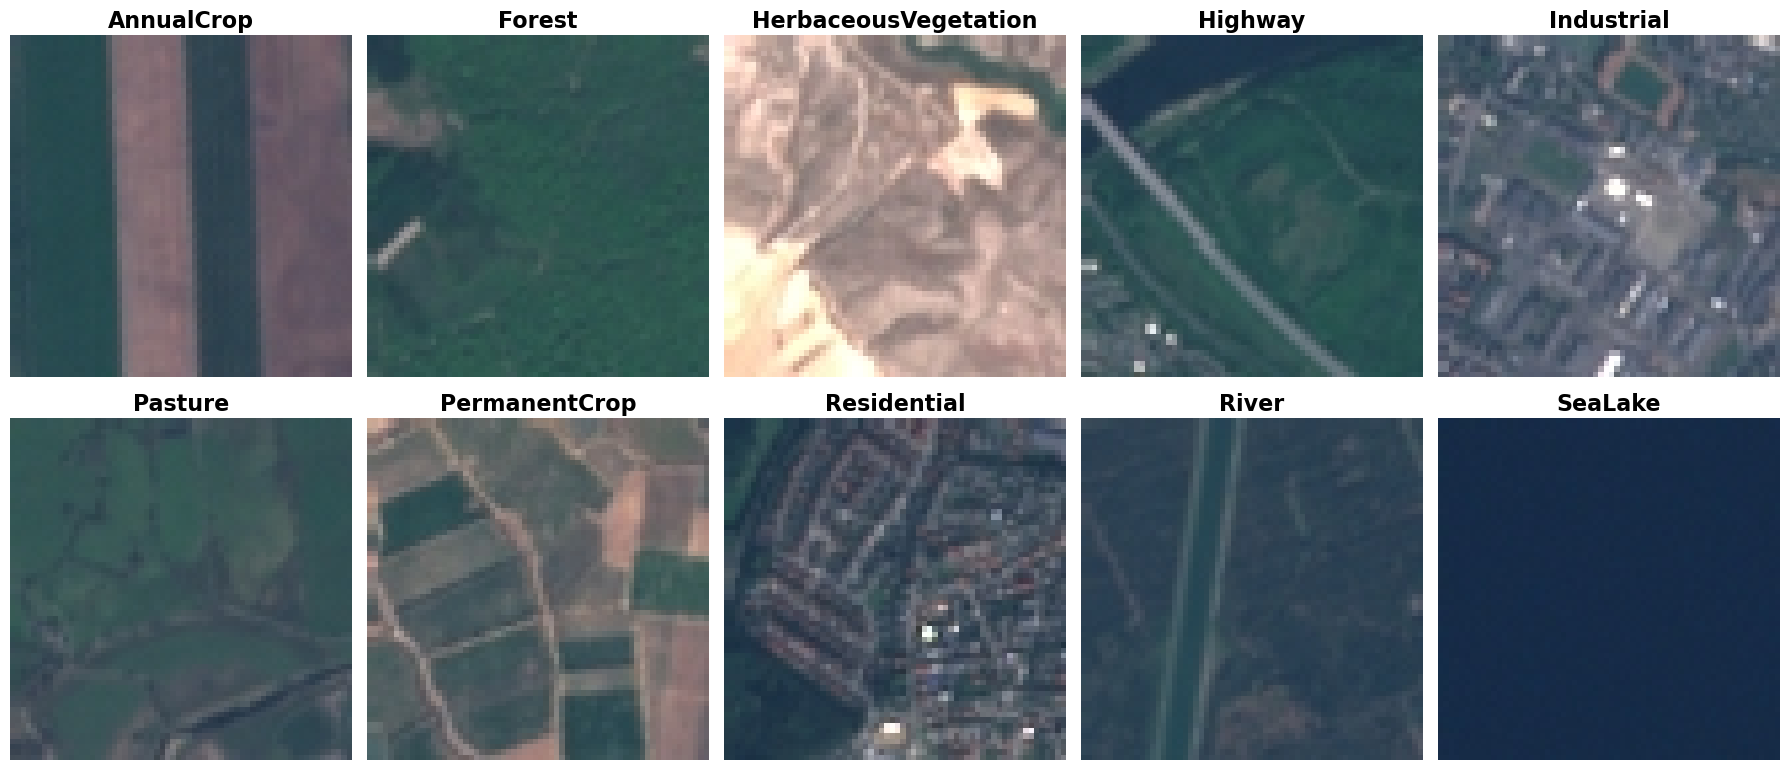

In [ ]:
# Función para visualizar una imagen de ejemplo por cada terreno
def visualizar_img(data): 
    
    """
    Visualiza una imagen representativa para cada tipo de terreno.
    Se espera que 'data' sea un dataset de TensorFlow que devuelva pares (image, label),
    y que 'label_names' sea una lista global con el nombre de las etiquetas.
    """
    
    #Diccionario para almacenar una imagen representativa para cada etiqueta numérica.
    images_by_type = {}
    
    # Iterear sobre el dataset para recolectar una imagen representativa para cada etiqueta númerica
    for image, label in data:
        nombre = label.numpy() # Obtener el entero de la etiqueta
        
        # Condicional para el caso que no este guardada la img
        if nombre not in images_by_type:
            # Convertimos el tensor de imagen a un array de NumPy para Matplotlib
            images_by_type[nombre] = image.numpy()
        
        # Si ya tenemos una img por cada clase, detenemos la iteración
        if len(images_by_type) == len(label_names):
            break
    
    # Número total de clases
    num_classes = len(label_names)
    
    # Definir la grilla; por ejemplo, para 10 clases puedes usar 2 filas y 5 columnas
    rows = 2
    cols = num_classes // rows

    plt.figure(figsize=(18, 8))
    for i in range(num_classes):
        try:
            plt.subplot(rows, cols, i+1)
            # Mostrar la imagen almacenada para la clase i
            plt.imshow(images_by_type[i])
            # Título usando el nombre textual de la clase
            plt.title(label_names[i], fontsize=16, fontweight='bold')
            plt.axis('off') # Quitar los ejes
        except Exception as e:
            print(f"Error al mostrar la imagen '{label_names[i]}': {e}")
        
    plt.tight_layout() # Ajustar espacio entre imágenes
    plt.show() # imprimir img
        
# Ejecutar función  
visualizar_img(parsed_dataset)

### **DATASET DE ENTRENAMIENTO Y PRUEBA (80% TRAIN Y 20% TEST)**
Se divide el conjunto total de imágenes de modo que el 80% de ellas se utilicen para ajustar el modelo, y el 20% restante para evaluar la capacidad de generalización del mismo. 
-	**Entrenamiento:** Se utilizar para que el modelo aprenda patrones y características de las imágenes. 

-	**Test:** Se utiliza para evaluar el desempeño del modelo en datos no conocidos, esto nos permite medir la capacidad del modelo para generalizar y detectar posibles problemas.


In [7]:
# Obtener la cantidad total de datos
total_count = parsed_dataset.reduce(tf.constant(0), lambda counter, _: counter + 1).numpy()
print("Total de muestras:", total_count)

Total de muestras: 27000


In [8]:
# Definir la proporción de entrenamiento y test (80% train, 20% test)
train_size = int(total_count * 0.8)
test_size = total_count - train_size

# Barajar (shuffle) el dataset para que la división sea aleatoria.
# Usamos el total_count como buffer_size para barajar todo el dataset.
shuffled_dataset = parsed_dataset.shuffle(buffer_size=total_count, reshuffle_each_iteration=False)

# Dividir el dataset:
train_dataset = shuffled_dataset.take(train_size)
test_dataset = shuffled_dataset.skip(train_size)

# Verificar las cantidad resultantes:
print("Muestras en train:", train_dataset.reduce(tf.constant(0), lambda counter, _: counter + 1).numpy())
print("Muestras en test:", test_dataset.reduce(tf.constant(0), lambda counter, _: counter + 1).numpy())

Muestras en train: 21600
Muestras en test: 5400


### **PREPROCESAMIENTO DE LOS DATOS**
Se realiza para transformar los datos crudos en una forma que sea mas adecuada para ser ingresadas el modelo. 
Mediante la normalización, aumento de datos y eliminar el ruido permite:
- Uniformidad de los datos
- Incrementar la cantidad y variedad.
- Mejorar la calidad de la visualización y reducir interferencias. 


#### Normalización
Consiste en ajustar los valores de intensidad de los píxeles a un rango estandarizado, generalmente [0, 1] o [-1, 1].

In [9]:
def normalizar_imagen(image, label):
    # Convertir la imagen a tipo float32 y normalizarla al rango [0,1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Suponiendo que `train_dataset` es un tf.data.Dataset que retorna (imagen, etiqueta)
train_dataset_normalizado = train_dataset.map(normalizar_imagen, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset_normalizado = test_dataset.map(normalizar_imagen, num_parallel_calls=tf.data.AUTOTUNE)

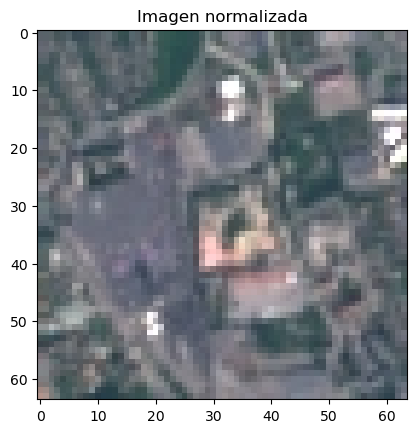

In [10]:
# Ejemplo de visualización:
def ejemplo_visualizacion(data, title):
    image, label = next(iter(data))
    plt.imshow(image.numpy())
    plt.title(title)
    plt.imshow(image, vmin=0, vmax=1)

ejemplo_visualizacion(train_dataset_normalizado, title="Imagen normalizada")

#### Aumento de Datos (Data Augmentation)
El aumento de datos es una técnica que simula "nuevos" ejemplos a partir de tus imágenes originales, realizando transformaciones geométricas o de color. Algunas transformaciones útiles son:

In [ ]:
def augment_image(image, label):
    # La imagen se invierte aleatoriamente de forma horizontal y vertical
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    
    image = tf.image.random_brightness(image, max_delta=0.1) # Ajustar brillo
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1) # Contraste
    image = tf.image.random_saturation(image, lower=0.9, upper=1.1) # Saturación
    image = tf.image.random_hue(image, max_delta=0.05) # Tono


    # Redimensionar la imagen (upscale) a un tamaño mayor sin agregar padding
    image = tf.image.resize(image, [128, 128])
    
    # Extraer un recorte aleatorio de 128x128
    image = tf.image.random_crop(image, size=[128, 128, 3])

    return image, label

# Integracion al dataset
train_dataset_augment = train_dataset_normalizado.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset_augment = test_dataset_normalizado.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


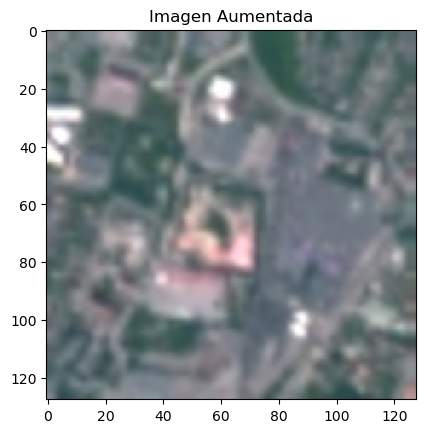

In [12]:
# Ejemplo de visualización:
ejemplo_visualizacion(train_dataset_augment, title="Imagen Aumentada")

#### Eliminar ruido
La eliminación de ruido implica usar técnicas de filtrado para suavizar la imagen y eliminar interferencias o variaciones no deseadas que puedan dificultar la extracción de características relevantes.

In [13]:
def gaussian_filter2d(image, kernel_size=5, sigma=1.0):
    # Se crea un kernel gaussiano 1D
    coords = tf.range(kernel_size, dtype=tf.float32) - (kernel_size - 1) / 2.0
    kernel = tf.exp(-(coords ** 2) / (2.0 * sigma ** 2))
    kernel /= tf.reduce_sum(kernel)
    
    # Se crea el kernel 2D
    kernel_2d = tf.tensordot(kernel, kernel, axes=0)
    kernel_2d = kernel_2d[:, :, tf.newaxis, tf.newaxis]
    channels = tf.shape(image)[-1]
    kernel_2d = tf.tile(kernel_2d, [1, 1, channels, 1])
    
    # Se añade dimensión de batch si es necesario
    if tf.rank(image)==3:
        image = image[tf.newaxis, ...]
    filtered = tf.nn.depthwise_conv2d(image, kernel_2d, strides=[1,1,1,1], padding='SAME')
    if filtered.shape[0]==1:
        filtered = tf.squeeze(filtered, axis=0)
    return filtered

def gaussian_kernel(size: int, sigma: float):
    """Crea un kernel gaussiano 2D."""
    x = tf.range(-size // 2 + 1, size // 2 + 1, dtype=tf.float32)
    y = tf.range(-size // 2 + 1, size // 2 + 1, dtype=tf.float32)
    xx, yy = tf.meshgrid(x, y)
    kernel = tf.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel = kernel / tf.reduce_sum(kernel)
    kernel = kernel[:, :, tf.newaxis, tf.newaxis]  # forma [size, size, 1, 1]
    return kernel

def apply_gaussian_denoise_tf(image, label, kernel_size=5, sigma=1.0):
    """
    Aplica filtro gaussiano a una imagen con TensorFlow puro.
    image: tensor [H, W, C]
    label: tensor (la etiqueta, se devuelve igual)
    """
    image = tf.image.convert_image_dtype(image, tf.float32)
    kernel = gaussian_kernel(kernel_size, sigma)  # kernel gaussiano [K, K, 1, 1]
    
    # Si la imagen tiene múltiples canales, aplicamos el filtro a cada canal por separado:
    channels = tf.split(image, image.shape[-1], axis=-1)  # lista de tensores [H,W,1]
    channels_filtered = []
    for ch in channels:
        ch = tf.expand_dims(ch, axis=0)  # [1, H, W, 1]
        filtered = tf.nn.conv2d(ch, kernel, strides=1, padding='SAME')
        filtered = tf.squeeze(filtered, axis=0)  # [H, W, 1]
        channels_filtered.append(filtered)
    
    denoised_image = tf.concat(channels_filtered, axis=-1)  # [H, W, C]
    
    return denoised_image, label



train_dataset_denoise = train_dataset_augment.map(
    lambda img, lbl: apply_gaussian_denoise_tf(img, lbl, kernel_size=7, sigma=1.5),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset_denoise = test_dataset_normalizado.map(
    lambda img, lbl: apply_gaussian_denoise_tf(img, lbl, kernel_size=7, sigma=1.5),
    num_parallel_calls=tf.data.AUTOTUNE
)

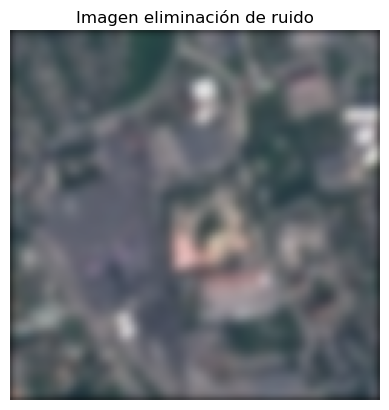

In [14]:
def ejemplo_visualizacion2(data, title):
    image, label = next(iter(data))
    # Si la imagen tiene una dimensión de batch de tamaño 1, la eliminamos
    if image.shape[0] == 1:
        image = tf.squeeze(image, axis=0)
    plt.imshow(image.numpy(), vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.show()
    
ejemplo_visualizacion2(train_dataset_denoise, title="Imagen eliminación de ruido")

### **CONVERTIR EL GENERADOR**
Para obtener X_train, y_train, X_test y y_test de tus generadores de datos train_dataset y test_dataset, se recorren los datos del generador y almacenarlos en listas.

*Se debe asegurar que tanto las imágenes de entrenamiento como las de test* *tengan el mismo tamaño, preferiblemente (128, 128, 3 ) para que sean* *compatibles con el modelo.* 

In [15]:
def preprocess_test_image(image, label):
    try:
        # Si 'image' es un string, se asume que es una ruta de archivo.
        if image.dtype == tf.string:
            image_raw = tf.io.read_file(image)
            # Usamos decode_jpeg (si tus imágenes son JPEG) y forzamos 3 canales.
            image = tf.image.decode_jpeg(image_raw, channels=3)
            # Establecemos una forma parcial: unknown alto/width, pero 3 canales.
            image.set_shape([None, None, 3])
            
        # Verifica el número de dimensiones con la información estática.
        current_ndims = image.get_shape().ndims
        # Si la información estática no está disponible, usa tf.rank.
        if current_ndims is None:
            current_ndims = tf.rank(image)
        
        # Si la imagen tiene menos de 3 dimensiones, se ajusta para convertir a RGB.
        if current_ndims < 3:
            # Esto debería manejar imágenes en escala de grises.
            image = tf.expand_dims(image, axis=-1)  # De [height, width] a [height, width, 1]
            image = tf.image.grayscale_to_rgb(image) # De [height, width, 1] a [height, width, 3]
        
        # Redimensionar la imagen a 128x128.
        image = tf.image.resize(image, [128, 128])
        
        # Fijar la forma final para asegurar compatibilidad con el modelo.
        image.set_shape([128, 128, 3])
        return image, label
    
    except Exception as e:
        # Si ocurre cualquier error, retornar una imagen negra por defecto.
        default_image = tf.zeros([128, 128, 3], dtype=tf.float32)
        return default_image, label

# Aplica la función al dataset:
train_dataset_denoise = train_dataset_denoise.map(
    preprocess_test_image, num_parallel_calls=tf.data.AUTOTUNE
)
test_dataset_denoise = test_dataset_denoise.map(
    preprocess_test_image, num_parallel_calls=tf.data.AUTOTUNE
)

In [24]:
# Función para convertir un generador en arrays 
def dataset_to_numpy(data):
    X_list = []
    y_list = []
    # Utilizamos as_numpy_iterator para iterar los elementos como arrays de NumPy
    for images, labels in data.as_numpy_iterator():
        batch_size = images.shape[0]
                # Si la primera dimensión de labels no coincide con el batch de imágenes, se replica.
        # Se asume que si labels es (1, num_clases), queremos replicar ese valor para cada imagen.
        if labels.ndim > 0 and labels.shape[0] != batch_size:
            labels = np.repeat(labels, batch_size, axis=0)
        X_list.append(images)
        y_list.append(labels)
        
    # Concatenar todos los batches en un solo arreglo a lo largo del primer eje (batch)
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    
    return X, y

# Agregar barching
    """_summary_
    Esto garantizará que cada labels tenga una forma (batch_size,) 
    en lugar de (), lo que evitará problemas al concatenar.
    """
batched_train_dataset = train_dataset_denoise.batch(32)
batched_test_dataset = test_dataset_denoise.batch(32) #-----

# Convertir el conjunto de datos de entrenamiento
X_train, y_train = dataset_to_numpy(batched_train_dataset.take(100))

# Convertir el conjunto de datos de prueba
X_test, y_test = dataset_to_numpy(batched_test_dataset.take(50))

#np.squeeze para quitar la dimensión de tamaño 1
#X_train = np.squeeze(X_train, axis=1)  # Ahora tendrá forma (128, 128, 128, 3)


print(f'Tamaño de X_train: {X_train.shape}')
print(f'Tamaño de y_train: {y_train.shape}')
print(f'Tamaño de X_test: {X_test.shape}')
print(f'Tamaño de y_test: {y_test.shape}')


Tamaño de X_train: (3200, 128, 128, 3)
Tamaño de y_train: (3200,)
Tamaño de X_test: (1600, 128, 128, 3)
Tamaño de y_test: (1600,)


### **REDES NEURONALES CONVOLUCIONALES**
Efectivas para la clasificación de imágenes, ya que están diseñadas para reconocer patrones en los datos espaciales.

#### Creación y Compilación del modelo
En este paso definimos el optimizador, es decir el método que se usará para actualizar los coeficientes de los filtros y de la Red Neuronal durante el entrenamiento.  

In [25]:
# Convertir las etiquetas a formato binario 
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)
    y_test = np.argmax(y_test, axis=1)

In [ ]:
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, SpatialDropout2D
from tensorflow.keras.regularizers import l2

# Definir el modelo
model = Sequential()

# Añadir capas convolucionales y de max pooling
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(SpatialDropout2D(0.25))  # Dropout espacial para conservar relaciones espaciales

# Segunda capa
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(SpatialDropout2D(0.25))

# Añadir capa de regularización Dropout
model.add(Dropout(0.25))

# Añadir capa de aplanado
model.add(Flatten())

# Capa densa con regularización L2 y Batch Normalization
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Capa de salida para clasificación multiclase
model.add(Dense(10, activation='softmax'))  # Para clasificación multiple, usa 'softmax'

# Compilar el modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Para multiclase
              metrics=['accuracy'])

c:\Users\crist\.conda\envs\proyecto\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 63, 63, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 30, 30, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,394,506 (28.21 MB)

 Trainable params: 7,394,058 (28.21 MB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
# Configuraciones de entrenamiento (hiperparámetros)
"""
    BATCH_SIZE: Número de ejemplos que se procesan en cada iteración 
    del entrenamiento. Un tamaño de batch de 128 implica que en cada 
    paso se utilizarán 128 ejemplos para actualizar los pesos.

    EPOCHS: Número de veces que se recorre todo el conjunto de entrenamiento.
    
    Verbose: Controla el nivel de datalle que se muestra durante el entrenamiento
        0	Silencioso: no muestra nada mientras entrena.
        1	Progreso detallado por época (barra de progreso con métricas).
        2	Muestra una línea por época (resumen final, sin barra).
"""

BATCH_SIZE = 128
EPOCHS = 20

# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1,
    validation_data=(X_test, y_test)
)

# Evaluar el modelo
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss: ', score[0])
print('Test accuracy: ', score[1])

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 156s 6s/step - accuracy: 0.3410 - loss: 2.4936 - val_accuracy: 0.1444 - val_loss: 2.7507
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.3835 - loss: 2.2651 - val_accuracy: 0.1262 - val_loss: 2.7489
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.4160 - loss: 2.1430 - val_accuracy: 0.1262 - val_loss: 2.7411
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.4725 - loss: 1.9866 - val_accuracy: 0.1262 - val_loss: 2.7721
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.4776 - loss: 1.8646 - val_accuracy: 0.1287 - val_loss: 2.7830
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5262 - loss: 1.7338 - val_accuracy: 0.1819 - val_loss: 2.8494
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.5709 - loss: 1.6052 - val_accuracy: 0.2050 - val_loss: 2.8664
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.6109 - loss: 1.4852 - val_accuracy: 0.1044 - val_loss

### **SUPPORT VECTOR MACHINE (SVM)**
La idea principal de un SVM es encontrar el hiperplano que separe las distintas clases con el mayor margen posible, lo que mejora la generalización del modelo.

##  **06. ANÁLISIS DEL DESEMPEÑO DE LOS MODELOS**

### **Resultados de la CNN**

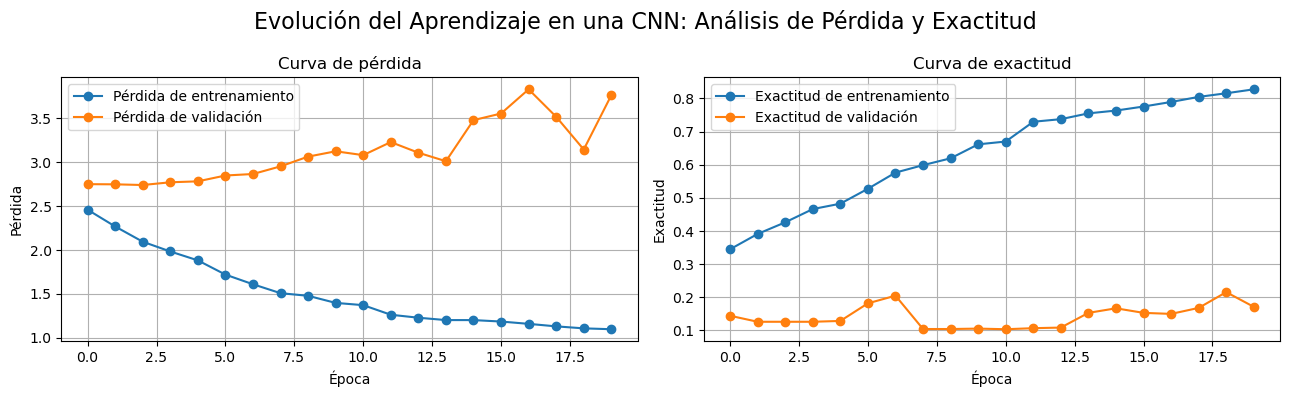

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

# Título general de la figura
fig.suptitle('Evolución del Aprendizaje en una CNN: Análisis de Pérdida y Exactitud', fontsize=16)

# Primer gráfico: Pérdida
axs[0].plot(history.history['loss'], 'o-', label='Pérdida de entrenamiento')
axs[0].plot(history.history['val_loss'], 'o-', label='Pérdida de validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].set_title('Curva de pérdida')
axs[0].legend()
axs[0].grid(True)

# Segundo gráfico: Exactitud
axs[1].plot(history.history['accuracy'], 'o-', label='Exactitud de entrenamiento')
axs[1].plot(history.history['val_accuracy'], 'o-', label='Exactitud de validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Exactitud')
axs[1].set_title('Curva de exactitud')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

Matriz de confusión: Una vez entrenado el modelo, puedes predecir sobre el conjunto de test y construir una matriz de confusión para ver el desempeño por clase. Generalmente se usa junto con librerías como sklearn.metrics y se visualiza con un heatmap usando, por ejemplo, seaborn.

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step


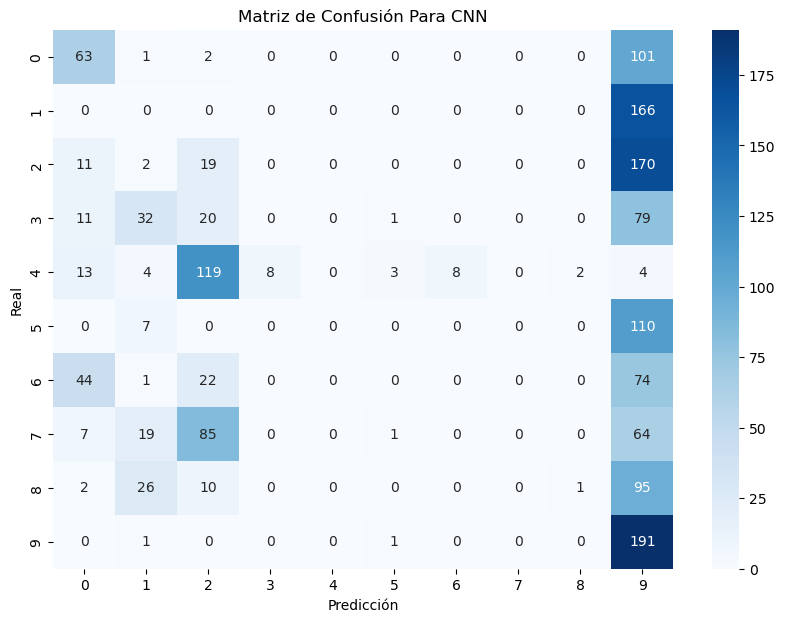

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Definir la función para graficar la matriz de confusión
def graficar_matriz_de_confusion(y_true, y_pred, etiquetas):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=etiquetas, yticklabels=etiquetas)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión Para CNN')
    plt.show()

# Obtener las predicciones
y_pred_prob = model.predict(X_test)  # Esto tiene forma (1600, nclases)
# Convertir las probabilidades a etiquetas de clase
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test

# Si quieres definir las etiquetas automáticamente según las clases presentes:
unique_labels = np.unique(y_test)  # Esto devolverá, por ejemplo, [0, 1, 2, 3, 4, 7, 8, 9]
etiquetas = [str(lbl) for lbl in unique_labels]

# Graficar la matriz de confusión
graficar_matriz_de_confusion(y_true, y_pred, etiquetas)

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Calcular accuracy
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

# Calcular precisión, recall y F1-Score (puedes usar average='macro' o 'weighted' para problemas multiclase)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
print("Precisión:", precision)
print("Recall:", recall)
print("F1-Score:", f1)


Accuracy: 0.17125
Precisión: 0.10198258895311638
Recall: 0.17125
F1-Score: 0.08954610147443981


c:\Users\crist\.conda\envs\proyecto\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


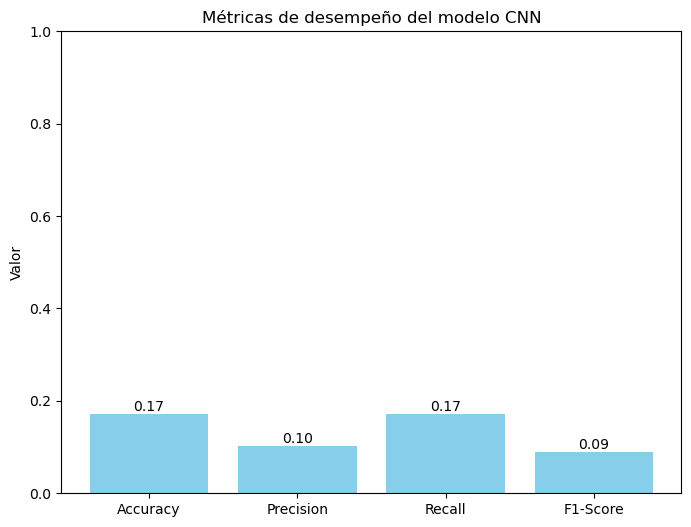

In [45]:
# Agrupar las métricas en una lista
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [acc, precision, recall, f1]

# Crear el gráfico de barras
plt.figure(figsize=(8, 6))
bars = plt.bar(metric_labels, metric_values, color='skyblue')

# Agregar los valores encima de cada barra para visualizarlos
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f}',
             ha='center', va='bottom')

plt.ylim(0, 1)  # Si las métricas están en el rango de 0 a 1
plt.title('Métricas de desempeño del modelo CNN')
plt.ylabel('Valor')
plt.show()


## **07. CONCLUSIONES**
Los datos obtenidos de la plataforma Kaggle, correspondiente a 10 clases de terrenos, tienen como objetivo determinar el tipo de terreno.

En relación al desempeño del modelo se obtiene:

- **Precisión ≈ 11.4%:** Significa que, de todas las predicciones positivas que hace el modelo, sólo el 11.4% son correctas.

- **Recall ≈ 11.1%:** Indica que, de todas las muestras que realmente pertenecen a la clase positiva, el modelo sólo identifica correctamente el 11.1% de ellas.

- **F1-Score ≈ 2.43%:** Al ser la media armónica de precisión y recall, un F1-score tan bajo resalta la incapacidad del modelo para equilibrar ambos aspectos.

Estos valores del modelo sugieren que sus predicciones están prácticamente al nivel del azar, las posibles causas que puede deberse estos resultados bajos son:
-	Dataset desequilibrado, es posible que el modelo se incline a predecir la clase mayoritaria.

-	Problemas en el preprocesamiento.

-	Hiperparámetros, es posibles que no sean los adecuados para capturar las características de las imágenes.

En resumen, el modelo no esta prendiendo lo suficiente para distinguir entre las diferentes clases y sus predicciones son errores o sesgadas a una clase en particular. Es recomendables revisar o ajustar tanto el preprocesamiento como la arquitectura del proyecto. 

